In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scqat.protocols.qubit_decoherence import (
    QubitDecoherenceAnalyzer,
    _rho11_model,
    _rho10_model,
)
from scqat.protocols.hankel_analysis import HankelAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
import os
from scqat.parsers.qualibrate_parser import repetition_data, parse_timestamp

In [2]:
# Define the path to the h5 file
h5_file_path = r'd:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\EP\Parametric_drive\QtoR\20260210_tomo\x180\#1520_LCH_qubit_parametric_drive_time_tomo_12_003758\ds_raw.h5'

# Check if file exists
if os.path.exists(h5_file_path):
    print(f"Found h5 file: {h5_file_path}")
else:
    print(f"File not found: {h5_file_path}")
    print(f"Current directory: {os.getcwd()}")
    print("Available files in current directory:")
    for file in os.listdir('.'):
        if file.endswith('.h5'):
            print(f"  - {file}")

# Load data using the qcat parser
try:
    ds = load_xarray_h5(h5_file_path)
    print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")
    print(f"Coordinates: {list(ds.coords.keys())}")
    print(f"Data variables: {list(ds.data_vars.keys())}")
    
    # Check if it has multiple qubits/repetitions
    if 'qubit' in ds.dims:
        print(f"\nFound {ds.sizes['qubit']} qubits in the dataset")
        qubit_data = repetition_data(ds, repetition_dim="qubit")
        print(f"Separated data into {len(qubit_data)} individual qubit datasets")
    else:
        qubit_data = [ds]  # Single dataset
        print("Single dataset (no qubit dimension)")
        
except Exception as e:
    print(f"Error loading file: {e}")
    ds = None

print(ds)

Found h5 file: d:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\EP\Parametric_drive\QtoR\20260210_tomo\x180\#1520_LCH_qubit_parametric_drive_time_tomo_12_003758\ds_raw.h5
Successfully loaded dataset with dimensions: {'driving_time': 150, 'driving_frequency': 11, 'basis': 3, 'qubit': 1}
Coordinates: ['driving_time', 'driving_frequency', 'basis', 'qubit']
Data variables: ['state']

Found 1 qubits in the dataset
Separated data into 1 individual qubit datasets
<xarray.Dataset> Size: 40kB
Dimensions:            (driving_time: 150, driving_frequency: 11, basis: 3,
                        qubit: 1)
Coordinates:
  * driving_time       (driving_time) int32 600B 20 60 100 ... 5900 5940 5980
  * driving_frequency  (driving_frequency) float64 88B 3.262e+08 ... 3.264e+08
  * basis              (basis) int32 12B 0 1 2
  * qubit              (qubit) object 8B 'q1'
Data variables:
    state              (qubit, driving_frequency, driving_time, basis) float64 40kB ...


C:\Users\shiau\AppData\Local\Temp\ipykernel_71008\4094730413.py:18: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Successfully loaded dataset with dimensions: {dict(ds.dims)}")


Creating heatmaps...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Available data variables: ['state']
Available coordinates: ['driving_time', 'driving_frequency', 'basis']


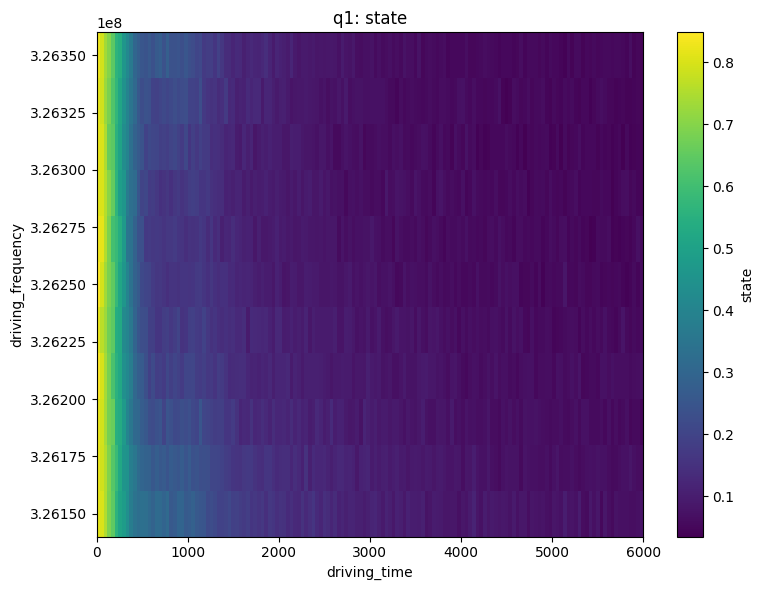


Heatmap creation complete!


In [3]:
print("Creating heatmaps...")

for i, sq_data in enumerate(qubit_data):
    # Select index 2 from basis coordinate if it exists
    if 'basis' in sq_data.coords:
        sq_data = sq_data.isel(basis=2)
        print(f"Selected basis index 2 from coordinate")

    try:
        qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        print(f"\nProcessing qubit {i}: {qubit_name}")
    except Exception:
        qubit_name = f"Dataset_{i}"
        print(f"\nProcessing dataset {i}")

    # Get available data variables and coordinates
    data_vars = list(sq_data.data_vars.keys())
    coords = [c for c in sq_data.coords.keys() if c != 'qubit']
    print(f"Available data variables: {data_vars}")
    print(f"Available coordinates: {coords}")

    # User-specified plotting parameters
    x_dim = "driving_time"
    y_dim = "driving_frequency"
    data_var = "state"

    # Extract the 2D data array and ensure axis ordering (y, x)
    da = sq_data[data_var]
    extra_dims = [d for d in da.dims if d not in (x_dim, y_dim)]
    if extra_dims:
        da = da.isel({d: 0 for d in extra_dims})
    da = da.transpose(y_dim, x_dim)

    x = da[x_dim].values
    y = da[y_dim].values
    Z = da.values

    fig, ax = plt.subplots(figsize=(8, 6))
    mesh = ax.pcolormesh(x, y, Z, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label=data_var)
    ax.set_xlabel(x_dim)
    ax.set_ylabel(y_dim)
    ax.set_title(f"{qubit_name}: {data_var}")
    plt.tight_layout()
    plt.show()

print("\nHeatmap creation complete!")


Creating 1D line plots (state vs driving_frequency)...
Selected basis index 2 from coordinate

Processing qubit 0: q1
Plotted time: 380.0 ns (requested: 400.0 ns)
Plotted time: 500.0 ns (requested: 500.0 ns)
Plotted time: 580.0 ns (requested: 600.0 ns)
Plotted time: 700.0 ns (requested: 700.0 ns)
Plotted time: 780.0 ns (requested: 800.0 ns)
Plotted time: 900.0 ns (requested: 900.0 ns)
Plotted time: 980.0 ns (requested: 1000.0 ns)
Plotted time: 1100.0 ns (requested: 1100.0 ns)
Plotted time: 1180.0 ns (requested: 1200.0 ns)
Plotted time: 1300.0 ns (requested: 1300.0 ns)
Plotted time: 1380.0 ns (requested: 1400.0 ns)
Target times average: calculated from 11 time points
All times average: calculated from 150 time points


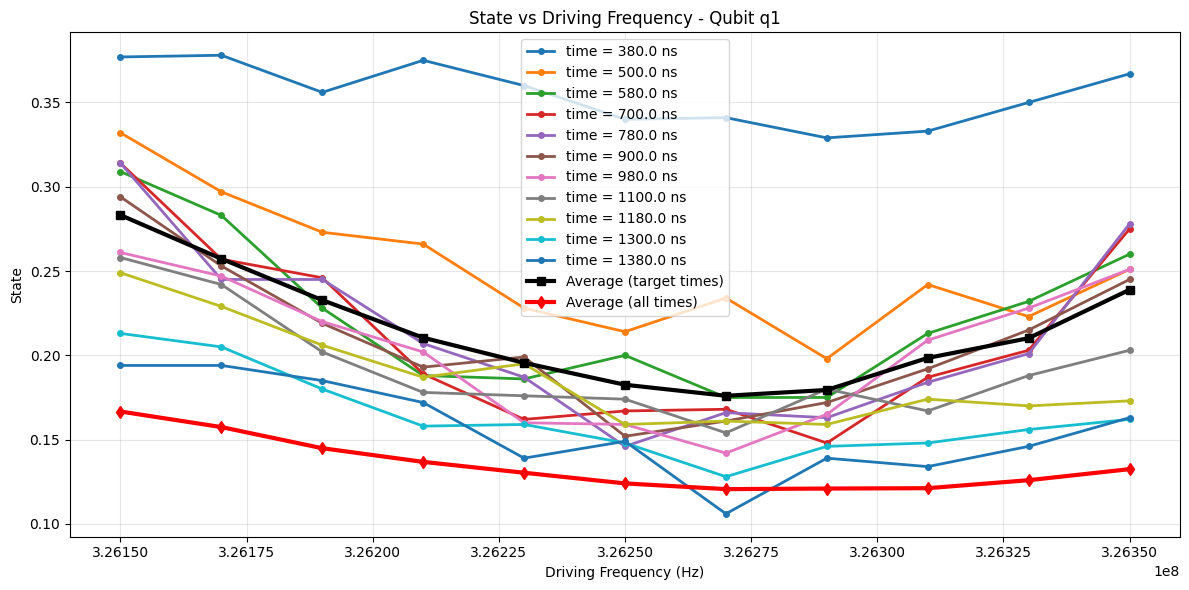

In [4]:
# Plot 1D line graphs for specific driving times
print("Creating 1D line plots (state vs driving_frequency)...")

# User-specified driving times to plot
target_times = [400,500,600,700,800,900,1000,1100,1200,1300,1400]  # Modify this list as needed (in ns)

for i, sq_data in enumerate(qubit_data):
    # Select index 2 from basis coordinate if it exists
    if 'basis' in sq_data.coords:
        sq_data = sq_data.isel(basis=2)
        print(f"Selected basis index 2 from coordinate")
    
    try:
        qubit_name = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
        print(f"\nProcessing qubit {i}: {qubit_name}")
    except:
        print(f"\nProcessing dataset {i}")
    
    # Create figure for line plots
    plt.figure(figsize=(12, 6))
    
    # Get driving_time and driving_frequency arrays
    driving_time = sq_data.coords["driving_time"].values
    driving_freq = sq_data.coords["driving_frequency"].values
    
    # Collect state_data arrays for averaging
    state_data_arrays = []
    
    # Plot line for each target time
    for time in target_times:
        # Find closest time in the data
        time_idx = np.argmin(np.abs(driving_time - time))
        actual_time = driving_time[time_idx]
        
        # Extract state data for this time
        state_data = sq_data["state"].isel(driving_time=time_idx).values
        state_data_arrays.append(state_data)
        
        # Plot the line
        plt.plot(driving_freq, state_data, 'o-', label=f'time = {actual_time:.1f} ns', linewidth=2, markersize=4)
        print(f"Plotted time: {actual_time:.1f} ns (requested: {time:.1f} ns)")
    
    # Calculate average state_data from target times (existing method)
    avg_state_data_target = np.mean(state_data_arrays, axis=0)
    
    # Calculate average state_data across all driving times (new method)
    avg_state_data_all_time = sq_data["state"].mean(dim="driving_time").values
    
    # Plot both averages
    plt.plot(driving_freq, avg_state_data_target, 's-', label='Average (target times)', linewidth=3, markersize=6, color='black')
    plt.plot(driving_freq, avg_state_data_all_time, 'd-', label='Average (all times)', linewidth=3, markersize=6, color='red')
    
    print(f"Target times average: calculated from {len(target_times)} time points")
    print(f"All times average: calculated from {len(driving_time)} time points")
    
    # Format the plot
    plt.xlabel('Driving Frequency (Hz)')
    plt.ylabel('State')
    plt.title(f'State vs Driving Frequency - Qubit {qubit_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



## 5. Per-`driving_frequency` Decoherence Analysis

Construct density-matrix elements from the three tomography rotations stored along
`basis` (X, Y, Z), then fit $\rho_{11}(t)$ versus `driving_time` to the
non-Markovian amplitude-damping model for each `driving_frequency`.

**Conventions used here**
- `basis = 0, 1, 2` correspond to X, Y, Z tomography readouts.
- `state` is $P(\lvert 1\rangle)$ in each rotated frame.
- $\rho_{11} = \text{state}[\text{basis}=2]$.
- $\langle X\rangle = 1 - 2\,\text{state}[0]$, $\langle Y\rangle = 1 - 2\,\text{state}[1]$.
- $\rho_{10} = (\langle X\rangle + i\,\langle Y\rangle)/2$ (computed but not fitted yet).

In [5]:
# --- Build density-matrix datasets per qubit ---
rho_datasets = []  # list of xr.Dataset, one per qubit

for i, sq_data in enumerate(qubit_data):
    if "basis" not in sq_data.coords:
        raise ValueError(f"Dataset {i} has no 'basis' coordinate; cannot build density matrix.")

    state = sq_data["state"]  # dims include: basis, driving_time, driving_frequency, ...

    # Tomography expectation values (drop the scalar 'basis' coord left over from isel)
    X = (1.0 - 2.0 * state.isel(basis=0)).drop_vars("basis", errors="ignore")
    Y = (1.0 - 2.0 * state.isel(basis=1)).drop_vars("basis", errors="ignore")
    rho_11 = (state.isel(basis=2).drop_vars("basis", errors="ignore") -0.045)/0.78
    rho_10_re = 0.5 * X
    rho_10_im = 0.5 * Y

    rho_ds = xr.Dataset(
        {
            "rho_11":    rho_11.astype(float),
            "rho_10_re": rho_10_re.astype(float),
            "rho_10_im": rho_10_im.astype(float),
        },
        attrs=dict(sq_data.attrs),
    )

    # Squeeze any singleton dims left over (e.g. trailing length-1 axes)
    rho_ds = rho_ds.squeeze(drop=True)
    rho_datasets.append(rho_ds)

    try:
        qname = sq_data["qubit"].values.item() if "qubit" in sq_data else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"
    print(f"[{qname}] rho dataset dims = {dict(rho_ds.sizes)}")

print(f"\nBuilt {len(rho_datasets)} density-matrix dataset(s).")

[q1] rho dataset dims = {'driving_time': 150, 'driving_frequency': 11}

Built 1 density-matrix dataset(s).


In [6]:
# --- Fit rho_11(t) vs the QubitDecoherenceAnalyzer model for every driving_frequency ---
from scqat.protocols.qubit_decoherence import QubitDecoherenceAnalyzer

decoherence_analyzer = QubitDecoherenceAnalyzer()

# Results keyed as: fit_results[qubit_index][driving_frequency_value] = {Gamma, Lambda, ...}
fit_results = []

for i, rho_ds in enumerate(rho_datasets):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    if "driving_frequency" not in rho_ds.coords or "driving_time" not in rho_ds.coords:
        raise ValueError(f"[{qname}] dataset must contain 'driving_frequency' and 'driving_time' coords.")

    freqs = rho_ds.coords["driving_frequency"].values
    per_freq = {}

    for f_val in freqs:
        # Slice and rename driving_time -> time to match the analyzer contract
        sub = rho_ds.sel(driving_frequency=f_val)
        sub = sub.rename({"driving_time": "time"})

        # Keep only rho_11 for the fit (rho_10 fitting deferred)
        fit_ds = sub[["rho_11"]]

        try:
            results, figs = decoherence_analyzer.analyze(fit_ds)
            for fig in figs.values():
                plt.close(fig)
            per_freq[float(f_val)] = results.get("rho_11", None)
        except Exception as exc:
            print(f"[{qname}] f={f_val:.3e} Hz: fit failed ({exc})")
            per_freq[float(f_val)] = None

    fit_results.append(per_freq)
    n_ok = sum(1 for v in per_freq.values() if v is not None)
    print(f"[{qname}] fitted {n_ok}/{len(freqs)} driving frequencies")

[q1] fitted 11/11 driving frequencies


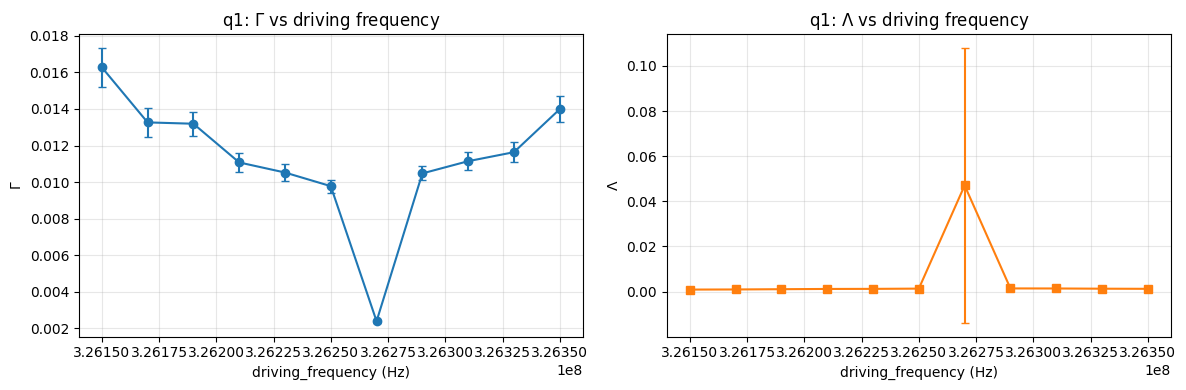

In [12]:
# --- Summary plots: Gamma and Lambda vs driving_frequency, per qubit ---
for i, per_freq in enumerate(fit_results):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    items = [(f, r) for f, r in per_freq.items() if r is not None]
    if not items:
        print(f"[{qname}] no successful fits to plot.")
        continue

    items.sort(key=lambda x: x[0])
    freqs = np.array([f for f, _ in items])
    Gamma = np.array([r["Gamma"] for _, r in items])
    Gamma_err = np.array([r["Gamma_err"] for _, r in items])
    Lambda = np.array([r["Lambda"] for _, r in items])
    Lambda_err = np.array([r["Lambda_err"] for _, r in items])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
    axes[0].errorbar(freqs, Gamma, yerr=Gamma_err, fmt="o-", capsize=3)
    axes[0].set_xlabel("driving_frequency (Hz)")
    axes[0].set_ylabel(r"$\Gamma$")
    axes[0].set_title(rf"{qname}: $\Gamma$ vs driving frequency")
    axes[0].grid(True, alpha=0.3)

    axes[1].errorbar(freqs, Lambda, yerr=Lambda_err, fmt="s-", color="C1", capsize=3)
    axes[1].set_xlabel("driving_frequency (Hz)")
    axes[1].set_ylabel(r"$\Lambda$")
    axes[1].set_title(rf"{qname}: $\Lambda$ vs driving frequency")
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

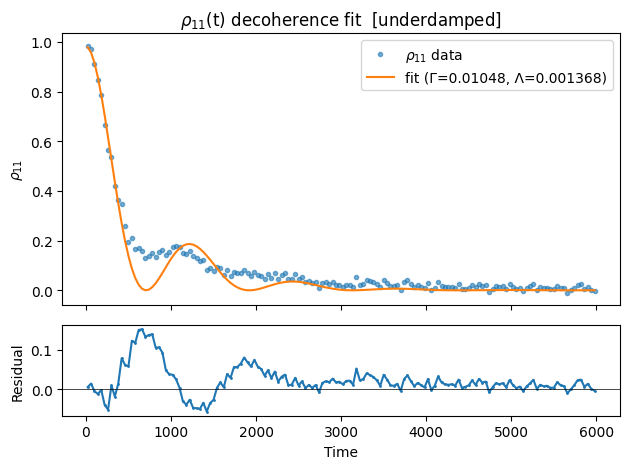

driving_frequency = 3.2629e+08 Hz
  Gamma  = 0.0104753 ± 0.00038
  Lambda = 0.00136767 ± 5.9e-05
  regime = underdamped


In [13]:
# --- Optional: inspect a single fit (data + model overlay) for one driving_frequency ---
qubit_idx = 0
target_freq = "best"  # "best" -> pick freq with minimum Gamma_err; or set a numeric value

rho_ds = rho_datasets[qubit_idx]
freqs = rho_ds.coords["driving_frequency"].values
per_freq = fit_results[qubit_idx]

if target_freq == "best":
    def _fit_chi(r):
        res = np.asarray(r["residuals"], dtype=float)
        if res.size == 0 or not np.all(np.isfinite(res)):
            return np.inf
        return float(np.sum(res ** 2))

    valid = [(f, r, _fit_chi(r)) for f, r in per_freq.items() if r is not None]
    valid = [v for v in valid if np.isfinite(v[2])]
    if not valid:
        raise RuntimeError("No successful fits available to pick a 'best' frequency.")
    f_val, _, _ = min(valid, key=lambda x: x[2])
elif target_freq is None:
    f_val = freqs[len(freqs) // 2]
else:
    f_val = freqs[np.argmin(np.abs(freqs - target_freq))]

sub = rho_ds.sel(driving_frequency=f_val).rename({"driving_time": "time"})
fit_ds = sub[["rho_11"]]
results, figs = decoherence_analyzer.analyze(fit_ds)
for fig in figs.values():
    display(fig)
    plt.close(fig)

res = results["rho_11"]
print(f"driving_frequency = {f_val:.6g} Hz")
print(f"  Gamma  = {res['Gamma']:.6g} ± {res['Gamma_err']:.2g}")
print(f"  Lambda = {res['Lambda']:.6g} ± {res['Lambda_err']:.2g}")
print(f"  regime = {res['regime']}")

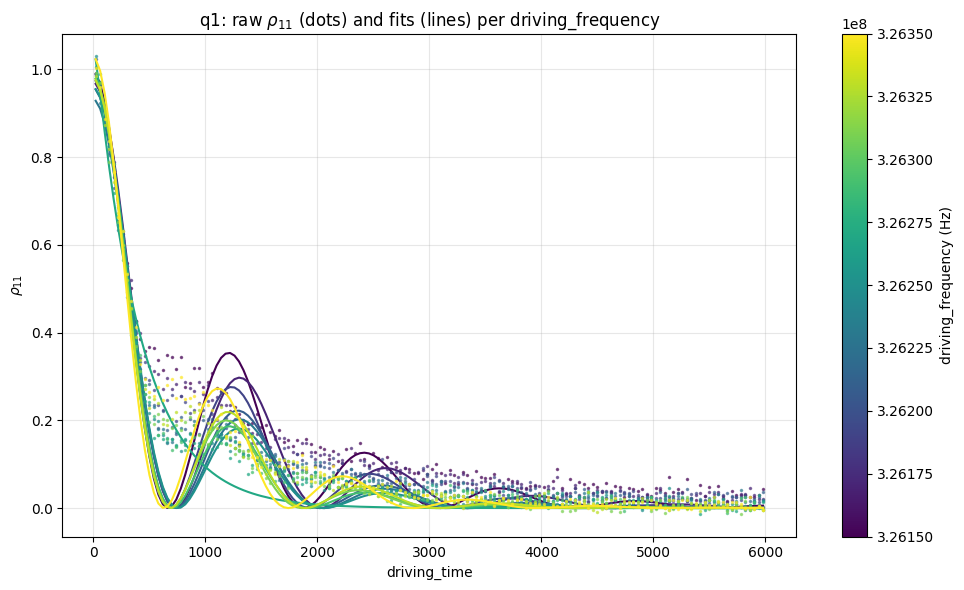

In [9]:
# --- Raw rho_11 traces and fit curves vs driving_time, colored by driving_frequency ---
from scqat.protocols.qubit_decoherence import _rho11_model

for i, (rho_ds, per_freq) in enumerate(zip(rho_datasets, fit_results)):
    try:
        qname = qubit_data[i]["qubit"].values.item() if "qubit" in qubit_data[i] else f"Dataset_{i}"
    except Exception:
        qname = f"Dataset_{i}"

    t = rho_ds.coords["driving_time"].values.astype(float)
    freqs_sorted = np.sort(np.array(list(per_freq.keys())))
    if len(freqs_sorted) == 0:
        continue

    cmap = plt.get_cmap("viridis")
    norm = plt.Normalize(vmin=freqs_sorted.min(), vmax=freqs_sorted.max())

    fig, ax = plt.subplots(figsize=(10, 6))
    for f_val in freqs_sorted:
        color = cmap(norm(f_val))
        y_data = rho_ds["rho_11"].sel(driving_frequency=f_val).values
        ax.plot(t, y_data, ".", ms=3, color=color, alpha=0.6)

        res = per_freq.get(f_val)
        if res is not None:
            y_fit = _rho11_model(t, res["Gamma"], res["Lambda"], res["rho_0"])
            ax.plot(t, y_fit, "-", lw=1.5, color=color)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("driving_frequency (Hz)")

    ax.set_xlabel("driving_time")
    ax.set_ylabel(r"$\rho_{11}$")
    ax.set_title(rf"{qname}: raw $\rho_{{11}}$ (dots) and fits (lines) per driving_frequency")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

### 5b. (Optional) Hankel mode decomposition for a single driving frequency

Mirror of the workflow in `EP_single.ipynb`. Uncomment to run on the slice
already prepared above.

In [10]:
# from scqat.protocols.hankel_analysis import HankelAnalyzer
#
# hankel_dataset = xr.Dataset(
#     {"signal": ("time", sub["rho_11"].values)},
#     coords={"time": sub.coords["time"].values},
# )
#
# hankel_analyzer = HankelAnalyzer()
# hankel_results, hankel_figs = hankel_analyzer.analyze(
#     hankel_dataset,
#     mode_method="relative",
#     recon_method="mpm",
#     threshold=2e-1,
#     energy_target=0.95,
#     eigval_threshold=1e-3,
# )
# for fig in hankel_figs.values():
#     display(fig)
#     plt.close(fig)
#
# print(f"Number of modes retained: {hankel_results['n_modes']}")
# for k, mode in enumerate(hankel_results["modes"]):
#     print(f"Mode {k}: f={mode['freq_hz']:.6g} Hz, decay={mode['decay_rate']:.6g}, "
#           f"A={mode['amplitude']:.6g}, phi={mode['phase']:.4f}")